# PA / PB1 peptide design — AF3 vs Boltz vs ColabDesign comparison

For each designed sequence that was predicted by AlphaFold 3, loads and compares confidence metrics from:
- **AF3**: `summary_confidences_*.json` (best model by ranking_score)
- **Boltz**: `confidence_*.json` from boltz validation runs
- **ColabDesign (AF2)**: protocol JSON files (i_ptm, ptm, plddt)

Sequence identity is used to match entries across the three predictors.

In [1]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Paths

In [ ]:
import sys, os, pathlib

# Load .env from project root (one level up from notebooks/)
_env_path = pathlib.Path('..') / '.env'
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line.startswith('export '):
            _line = _line[7:]
        if '=' in _line and not _line.startswith('#'):
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip())

sys.path.append('..')
import config

PRJ_DIR    = pathlib.Path('..').resolve()
SCRIPT_DIR = PRJ_DIR / 'notebooks'
COLAB_DIR  = pathlib.Path(config.RESULTS_DIR)
BOLTZ_DIR  = pathlib.Path(config.BOLTZ_RESULTS_DIR)
AF3_DIR    = pathlib.Path(config.AF3_RESULTS_DIR)

# Subfolders to skip in AF3_DIR
AF3_SKIP = {'trash', 'fold_2026_03_12_PB1wt'}

print(f'COLAB_DIR  exists: {COLAB_DIR.exists()}  ({len(list(COLAB_DIR.rglob("*.json")))} JSON files)')
print(f'BOLTZ_DIR  exists: {BOLTZ_DIR.exists()}  ({len(list(BOLTZ_DIR.rglob("boltz_results_pa_*")))} result dirs)')
print(f'AF3_DIR    exists: {AF3_DIR.exists()}  ({sum(1 for d in AF3_DIR.iterdir() if d.is_dir() and d.name not in AF3_SKIP) if AF3_DIR.exists() else 0} sequence folders)')

COLAB_DIR  exists: True  (18 JSON files)
BOLTZ_DIR  exists: True  (364 result dirs)
AF3_DIR    exists: True  (33 sequence folders)


## 2. Load ColabDesign results

In [3]:
def load_colab_results(colab_dir: pathlib.Path) -> pd.DataFrame:
    """Load all ColabDesign protocol JSONs → DataFrame indexed by (name, seq)."""
    rows = []
    for jf in sorted(colab_dir.rglob('*.json')):
        proto = jf.stem
        data  = json.loads(jf.read_text())
        for i, entry in enumerate(data.get('results', [])):
            seq = entry.get('seq', '')
            if not seq:
                continue
            rows.append({
                'name'         : f'{proto}_{i}',
                'protocol'     : proto,
                'seq'          : seq.upper(),
                'colab_iptm'   : entry.get('i_ptm'),
                'colab_ptm'    : entry.get('ptm'),
                'colab_plddt'  : entry.get('plddt'),
                'energy'       : entry.get('energy'),
                'loss_af'      : entry.get('loss_af'),
            })
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df)} ColabDesign entries from {df["protocol"].nunique()} protocols')
    return df

df_colab = load_colab_results(COLAB_DIR)
df_colab.head(3)

Loaded 463 ColabDesign entries from 12 protocols


,name,protocol,seq,colab_iptm,colab_ptm,colab_plddt,energy,loss_af
0,gen_colabonly_0,gen_colabonly,AAGGPAALVLLLCLD,0.395,0.898,0.391,5.030,3.829
1,gen_colabonly_1,gen_colabonly,SSGGALGDALLVMLN,0.349,0.879,0.377,12.613,3.902
2,gen_colabonly_2,gen_colabonly,AAGGGDALLCLLMLD,0.376,0.879,0.378,5.422,3.779


## 3. Load Boltz results

In [4]:
def load_boltz_results(boltz_dir: pathlib.Path) -> pd.DataFrame:
    """Load boltz confidence JSONs → DataFrame indexed by name."""
    rows = []
    for result_dir in sorted(boltz_dir.rglob('boltz_results_pa_*')):
        name = result_dir.name.removeprefix('boltz_results_pa_')
        conf_glob = list(result_dir.glob(f'predictions/pa_{name}/confidence_pa_{name}_model_0.json'))
        if not conf_glob:
            print(f'  [missing] {result_dir.name}')
            continue
        c = json.loads(conf_glob[0].read_text())
        rows.append({
            'name'              : name,
            'boltz_confidence'  : c.get('confidence_score'),
            'boltz_ptm'         : c.get('ptm'),
            'boltz_iptm'        : c.get('iptm'),
            'boltz_plddt'       : c.get('complex_plddt'),
            'boltz_iplddt'      : c.get('complex_iplddt'),
            'boltz_pde'         : c.get('complex_pde'),
            'boltz_ipde'        : c.get('complex_ipde'),
            'boltz_ptm_PA'      : c.get('chains_ptm', {}).get('0'),
            'boltz_ptm_pep'     : c.get('chains_ptm', {}).get('1'),
            'boltz_iptm_cross'  : c.get('pair_chains_iptm', {}).get('1', {}).get('0'),
        })
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df)} Boltz entries')
    return df

df_boltz = load_boltz_results(BOLTZ_DIR)
df_boltz.head(3)

Loaded 364 Boltz entries


,name,boltz_confidence,boltz_ptm,boltz_iptm,boltz_plddt,boltz_iplddt,boltz_pde,boltz_ipde,boltz_ptm_PA,boltz_ptm_pep,boltz_iptm_cross
0,gen_colabonly_0,0.897,0.949,0.952,0.884,0.860,0.362,1.143,0.949,0.968,0.952
1,gen_colabonly_1,0.819,0.936,0.620,0.869,0.799,0.495,5.283,0.947,0.743,0.620
2,gen_colabonly_10,0.895,0.935,0.939,0.885,0.831,0.389,1.403,0.935,0.959,0.939


## 4. Load AF3 results

In [5]:
def read_chain_b_seq(msa_dir: pathlib.Path) -> str:
    """Read peptide sequence (chain B) from unpaired MSA a3m file."""
    a3m_files = list(msa_dir.rglob('*_unpaired_msa_chains_b.a3m'))
    if not a3m_files:
        return ''
    lines = a3m_files[0].read_text().splitlines()
    for i, line in enumerate(lines):
        if line.startswith('>query') or (i == 0 and line.startswith('>')):
            if i + 1 < len(lines):
                return lines[i + 1].strip().upper()
    return ''


def load_af3_results(af3_dir: pathlib.Path, skip: set) -> pd.DataFrame:
    """
    For each sequence folder in af3_dir:
      - read peptide sequence from chain-B unpaired MSA
      - load all summary_confidences_*.json, pick best by ranking_score
      - extract AF3 confidence metrics
    Returns a DataFrame with one row per sequence.
    """
    rows = []
    for folder in sorted(af3_dir.iterdir()):
        if not folder.is_dir() or folder.name in skip:
            continue

        # Peptide sequence from MSA
        seq = read_chain_b_seq(folder / 'msas')
        if not seq:
            print(f'  [skip — no chain B MSA] {folder.name}')
            continue

        # Load all 5 model summary_confidences, pick best by ranking_score
        conf_files = sorted(folder.glob('*_summary_confidences_*.json'))
        if not conf_files:
            print(f'  [skip — no confidences] {folder.name}')
            continue

        best, best_score = None, -np.inf
        for cf in conf_files:
            c = json.loads(cf.read_text())
            score = c.get('ranking_score', -np.inf)
            if score > best_score:
                best_score = score
                best = c

        # Cross-chain iptm: chain_pair_iptm[peptide][PA] = [1][0]
        cpi = best.get('chain_pair_iptm', [[None, None], [None, None]])
        cpm = best.get('chain_pair_pae_min', [[None, None], [None, None]])
        cpt = best.get('chain_ptm', [None, None])
        cia = best.get('chain_iptm', [None, None])

        rows.append({
            'seq'                  : seq,
            'af3_folder'           : folder.name,
            'af3_iptm'             : best.get('iptm'),
            'af3_ptm'              : best.get('ptm'),
            'af3_ranking_score'    : best.get('ranking_score'),
            'af3_has_clash'        : best.get('has_clash'),
            'af3_frac_disordered'  : best.get('fraction_disordered'),
            'af3_ptm_PA'           : cpt[0] if len(cpt) > 0 else None,
            'af3_ptm_pep'          : cpt[1] if len(cpt) > 1 else None,
            'af3_iptm_PA'          : cia[0] if len(cia) > 0 else None,
            'af3_iptm_pep'         : cia[1] if len(cia) > 1 else None,
            # cross-chain: peptide (row 1) evaluating interface with PA (col 0)
            'af3_iptm_cross'       : cpi[1][0] if len(cpi) > 1 and len(cpi[1]) > 0 else None,
            'af3_pae_min_cross'    : cpm[1][0] if len(cpm) > 1 and len(cpm[1]) > 0 else None,
        })
        print(f'  {seq}  →  iptm={best.get("iptm"):.3f}  ptm={best.get("ptm"):.3f}  ranking={best.get("ranking_score"):.3f}')

    df = pd.DataFrame(rows)
    print(f'\nLoaded {len(df)} AF3 entries')
    return df

df_af3 = load_af3_results(AF3_DIR, AF3_SKIP)
df_af3.head()

  CCGDPALLFFLMCCE  →  iptm=0.620  ptm=0.840  ranking=0.720
  LIGGPALEVLLCLFC  →  iptm=0.720  ptm=0.860  ranking=0.800
  NWGSPAALLLFMCTC  →  iptm=0.720  ptm=0.860  ranking=0.810
  SHGYVYDALWNMEVL  →  iptm=0.820  ptm=0.860  ranking=0.880
  YHPQVEGSPELAMFL  →  iptm=0.570  ptm=0.850  ranking=0.680
  YVCNVFDAFARMEVL  →  iptm=0.600  ptm=0.850  ranking=0.710
  AWGGPCLLLNFLEEL  →  iptm=0.640  ptm=0.850  ranking=0.740
  DHGYVYDLHLNQEVL  →  iptm=0.680  ptm=0.860  ranking=0.760
  EIGGLDAMLNYLLFC  →  iptm=0.600  ptm=0.850  ranking=0.710
  FYLSLMSSPNMKELA  →  iptm=0.550  ptm=0.850  ranking=0.660
  AISGPALEVLYCIFC  →  iptm=0.820  ptm=0.860  ranking=0.880
  CHCNVHEHFHRTELL  →  iptm=0.530  ptm=0.850  ranking=0.650
  CHMNRYWHFCRKKQL  →  iptm=0.660  ptm=0.850  ranking=0.750
  CVCNVFWHFARKGLL  →  iptm=0.680  ptm=0.850  ranking=0.770
  CVCNVYDHFARKEML  →  iptm=0.720  ptm=0.850  ranking=0.800
  CVCNVYWHFSRKGLL  →  iptm=0.770  ptm=0.860  ranking=0.850
  CWMNRYWHPCAKEWA  →  iptm=0.580  ptm=0.840  ranking=0.6

,seq,af3_folder,af3_iptm,af3_ptm,af3_ranking_score,af3_has_clash,af3_frac_disordered,af3_ptm_PA,af3_ptm_pep,af3_iptm_PA,af3_iptm_pep,af3_iptm_cross,af3_pae_min_cross
0,CCGDPALLFFLMCCE,fold_2026_04_08_CCGDPALLFFLMCCE,0.620,0.840,0.720,0.000,0.110,0.850,0.020,0.620,0.620,0.620,6.020
1,LIGGPALEVLLCLFC,fold_2026_04_08_LIGGPALEVLLCLFC,0.720,0.860,0.800,0.000,0.120,0.860,0.020,0.720,0.720,0.720,5.020
2,NWGSPAALLLFMCTC,fold_2026_04_08_NWGSPAALLLFMCTC,0.720,0.860,0.810,0.000,0.120,0.870,0.020,0.720,0.720,0.720,5.060
3,SHGYVYDALWNMEVL,fold_2026_04_08_SHGYVYDALWNMEVL,0.820,0.860,0.880,0.000,0.110,0.860,0.020,0.820,0.820,0.820,3.830
4,YHPQVEGSPELAMFL,fold_2026_04_08_YHPQVEGSPELAMFL,0.570,0.850,0.680,0.000,0.110,0.860,0.010,0.570,0.570,0.570,7.820


## 5. Merge all three predictors by sequence

In [6]:
# Average duplicate names in each table, then outer-merge so all entries are kept
def avg_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes('number').columns.tolist()
    str_cols = [c for c in df.columns if c not in num_cols and c != 'name']
    agg = {c: 'mean' for c in num_cols}
    agg.update({c: 'first' for c in str_cols})
    return df.groupby('name', as_index=False).agg(agg)

df_colab_u = avg_duplicates(df_colab)
df_boltz_u = avg_duplicates(df_boltz)

# Merge ColabDesign + Boltz on name (outer: keep all entries)
df_cb = df_colab_u.merge(df_boltz_u, on='name', how='outer')

# Merge with AF3 on seq (upper-case normalised)
df = df_cb.merge(df_af3, on='seq', how='outer')

n_both = (df['loss_af'].notna() & df['boltz_confidence'].notna()).sum()
n_colab_only = (df['loss_af'].notna() & df['boltz_confidence'].isna()).sum()
n_boltz_only = (df['loss_af'].isna()  & df['boltz_confidence'].notna()).sum()
print(f'{len(df)} total entries | {n_both} both colab+boltz | {n_colab_only} colab-only | {n_boltz_only} boltz-only')
print(f'Protocols represented: {sorted(df["protocol"].dropna().unique())}')
df[['name', 'protocol', 'seq']].head(15)

45 sequences with predictions from all three predictors
Protocols represented: ['gen_colabonly', 'gen_energy_A', 'gen_energy_B', 'gen_energy_C', 'opt_anneal_energy_A', 'opt_anneal_energy_B', 'opt_anneal_energy_C', 'opt_anneal_noenergy', 'opt_hard_energy_A', 'opt_hard_energy_B', 'opt_hard_energy_C', 'opt_hard_noenergy']


,name,protocol,seq
0,gen_colabonly_15,gen_colabonly,CCGDPALLFFLMCCE
1,gen_energy_B_5,gen_energy_B,AWGGPCLLLNFLEEL
2,gen_energy_C_0,gen_energy_C,NWGSPAALLLFMCTC
3,gen_energy_C_9,gen_energy_C,AISGPALEVLYCIFC
4,gen_energy_C_13,gen_energy_C,LIGGPALEVLLCLFC
5,gen_energy_C_13,gen_energy_C,LIGGPALEVLLCLFC
6,gen_energy_C_16,gen_energy_C,AISGPALEVLYCIFC
7,gen_energy_C_17,gen_energy_C,EIGGLDAMLNYLLFC
8,opt_anneal_energy_A_2,opt_anneal_energy_A,DHGYVYDLHLNQEVL
9,opt_anneal_energy_A_5,opt_anneal_energy_A,SVCNVFDFFARCELL


In [7]:
# Summary table of all metrics
metric_cols = [
    'colab_iptm', 'colab_ptm', 'colab_plddt',
    'boltz_iptm', 'boltz_ptm', 'boltz_iptm_cross', 'boltz_confidence', 'boltz_plddt',
    'af3_iptm', 'af3_ptm', 'af3_iptm_cross', 'af3_ranking_score',
]
display_cols = ['seq', 'protocol'] + [c for c in metric_cols if c in df.columns]
df[display_cols].sort_values('boltz_iptm_cross', ascending=False)

,seq,protocol,colab_iptm,colab_ptm,colab_plddt,boltz_iptm,boltz_ptm,boltz_iptm_cross,boltz_confidence,boltz_plddt,af3_iptm,af3_ptm,af3_iptm_cross,af3_ranking_score
0,CCGDPALLFFLMCCE,gen_colabonly,0.441,0.899,0.401,0.965,0.944,0.965,0.882,0.862,0.620,0.840,0.620,0.720
16,FYLSLMSSPNMKELA,opt_anneal_noenergy,0.207,0.874,0.295,0.964,0.933,0.964,0.889,0.870,0.550,0.850,0.550,0.660
8,DHGYVYDLHLNQEVL,opt_anneal_energy_A,0.115,0.886,0.327,0.963,0.939,0.963,0.899,0.883,0.680,0.860,0.680,0.760
1,AWGGPCLLLNFLEEL,gen_energy_B,0.354,0.895,0.374,0.962,0.952,0.962,0.906,0.892,0.640,0.850,0.640,0.740
13,YVCNVFLHFARKETL,opt_anneal_energy_C,0.150,0.886,0.385,0.957,0.942,0.957,0.902,0.889,0.760,0.870,0.760,0.840
44,CVCNVFWHFARKGLL,opt_hard_energy_C,0.128,0.886,0.403,0.956,0.948,0.956,0.906,0.894,0.680,0.850,0.680,0.770
25,LIGGPALEVLLCLFC,gen_energy_C,0.429,0.889,0.424,0.955,0.930,0.955,0.891,0.875,0.680,0.850,0.680,0.770
5,LIGGPALEVLLCLFC,gen_energy_C,0.429,0.898,0.427,0.955,0.930,0.955,0.891,0.875,0.680,0.850,0.680,0.770
24,LIGGPALEVLLCLFC,gen_energy_C,0.429,0.889,0.424,0.955,0.930,0.955,0.891,0.875,0.720,0.860,0.720,0.800
4,LIGGPALEVLLCLFC,gen_energy_C,0.429,0.898,0.427,0.955,0.930,0.955,0.891,0.875,0.720,0.860,0.720,0.800


In [8]:

# Summary table of all metrics
metric_cols = [
    'colab_iptm', 'boltz_iptm_cross', 'af3_iptm_cross','af3_ranking_score','af3_ptm'
]
display_cols = ['seq', 'protocol'] + [c for c in metric_cols if c in df.columns]
df[display_cols].sort_values('af3_iptm_cross', ascending=False)

,seq,protocol,colab_iptm,boltz_iptm_cross,af3_iptm_cross,af3_ranking_score,af3_ptm
3,AISGPALEVLYCIFC,gen_energy_C,0.678,0.907,0.820,0.880,0.860
12,SHGYVYDALWNMEVL,opt_anneal_energy_C,0.495,0.947,0.820,0.880,0.860
6,AISGPALEVLYCIFC,gen_energy_C,0.678,0.936,0.820,0.880,0.860
23,AISGPALEVLYCIFC,gen_energy_C,0.678,0.907,0.820,0.880,0.860
26,AISGPALEVLYCIFC,gen_energy_C,0.678,0.936,0.820,0.880,0.860
36,EHMPRYWQFCRAWFL,opt_anneal_noenergy,0.739,0.766,0.810,0.870,0.860
29,CVCNVYWHFSRKGLL,opt_anneal_energy_B,0.144,0.893,0.770,0.850,0.860
43,CVCNVYWHFSRKGLL,opt_hard_energy_C,0.145,0.932,0.770,0.850,0.860
30,YVCNVFLHFARKETL,opt_anneal_energy_C,0.150,0.947,0.760,0.840,0.870
13,YVCNVFLHFARKETL,opt_anneal_energy_C,0.150,0.957,0.760,0.840,0.870


## 6. Cross-predictor scatter plots

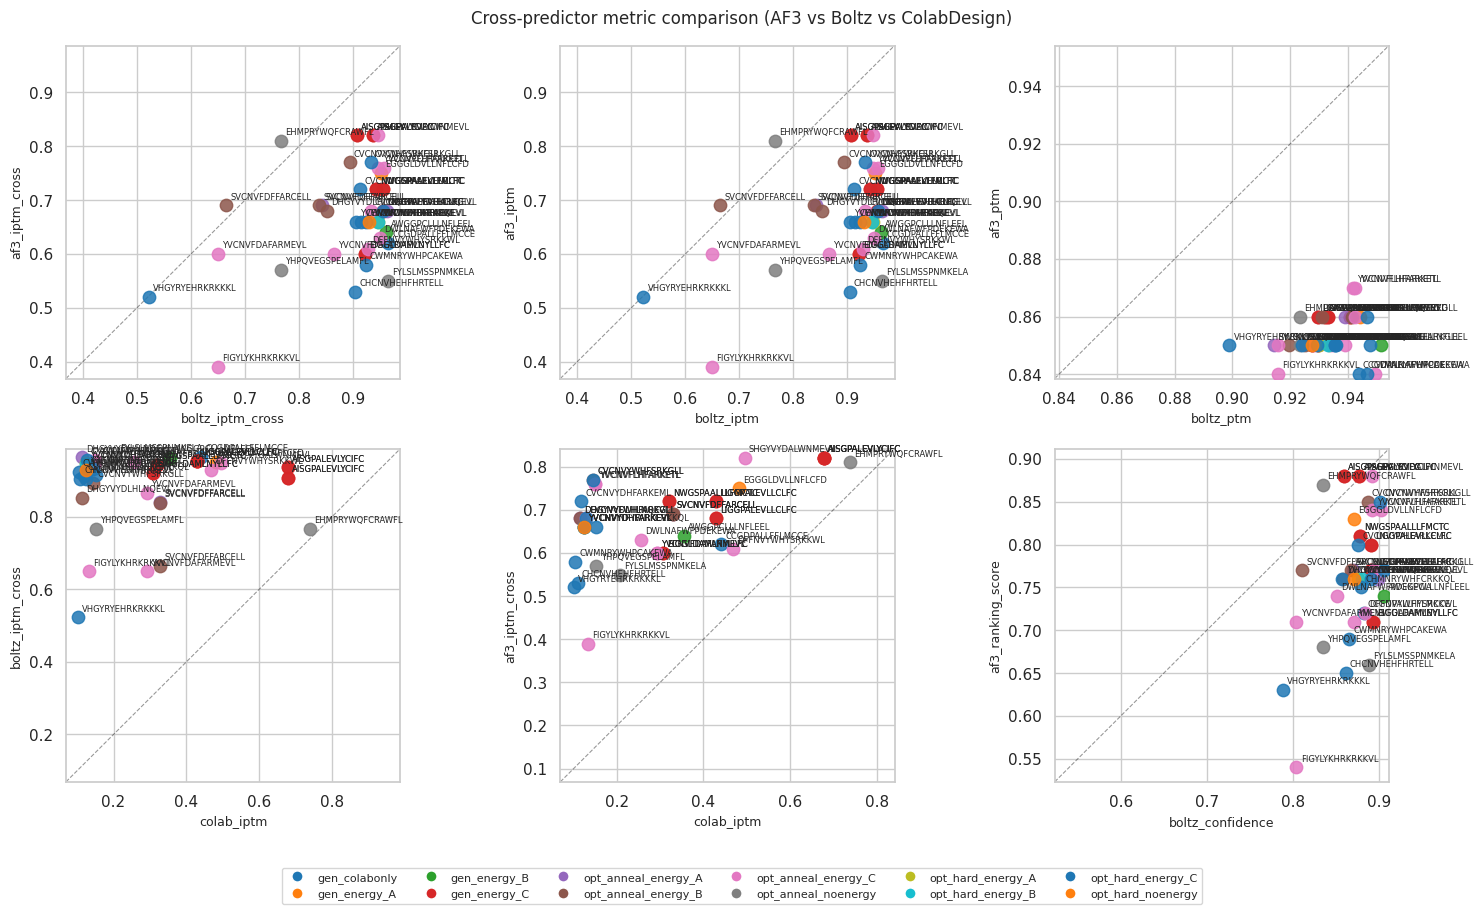

In [9]:
# Color map by protocol
protocols = df['protocol'].unique()
palette   = dict(zip(sorted(protocols), sns.color_palette('tab10', len(protocols))))

def scatter_compare(ax, x_col, y_col, df, palette):
    """Scatter plot colored by protocol with sequence labels."""
    for proto, grp in df.groupby('protocol'):
        ax.scatter(grp[x_col], grp[y_col], label=proto,
                   color=palette.get(proto, 'grey'), s=80, alpha=0.85, zorder=3)
    for _, row in df.iterrows():
        ax.annotate(row['seq'], (row[x_col], row[y_col]),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')
    # identity line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4, zorder=1)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)

pairs = [
    ('boltz_iptm_cross', 'af3_iptm_cross'),
    ('boltz_iptm',       'af3_iptm'),
    ('boltz_ptm',        'af3_ptm'),
    ('colab_iptm',       'boltz_iptm_cross'),
    ('colab_iptm',       'af3_iptm_cross'),
   ('boltz_confidence', 'af3_ranking_score'),
]
# filter to columns that actually exist
pairs = [(x, y) for x, y in pairs if x in df.columns and y in df.columns]

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    scatter_compare(ax, x_col, y_col, df, palette)

for ax in axes[len(pairs):]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                      markersize=8, label=p) for p, c in palette.items()]
fig.legend(handles=handles, loc='lower center', ncol=min(6, len(palette)),
           fontsize=8, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Cross-predictor metric comparison (AF3 vs Boltz vs ColabDesign)', fontsize=12)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 7. Bar chart — iptm_cross per sequence across predictors

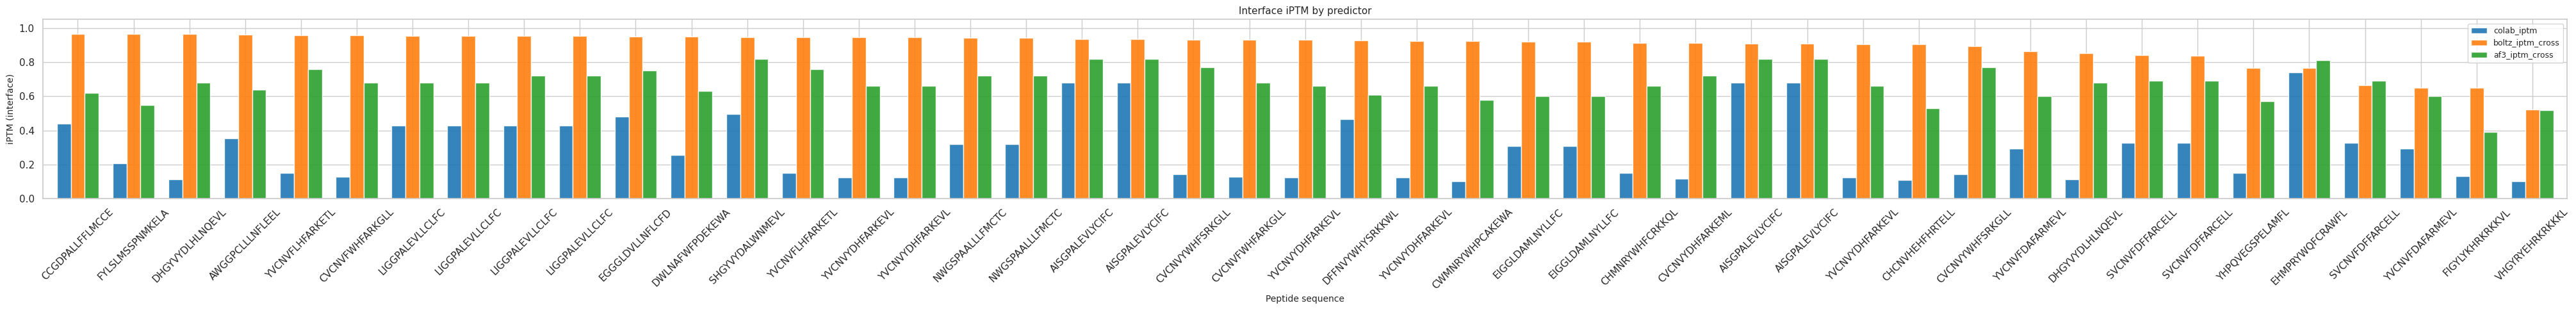

In [10]:
iptm_cols = [c for c in ['colab_iptm', 'boltz_iptm_cross', 'af3_iptm_cross'] if c in df.columns]

df_plot = df[['seq'] + iptm_cols].set_index('seq').sort_values(
    'boltz_iptm_cross' if 'boltz_iptm_cross' in iptm_cols else iptm_cols[0],
    ascending=False
)

ax = df_plot.plot(kind='bar', figsize=(max(10, len(df) * 0.9), 5),
                  width=0.75, edgecolor='white', alpha=0.9)
ax.set_xlabel('Peptide sequence', fontsize=10)
ax.set_ylabel('iPTM (interface)', fontsize=10)
ax.set_title('Interface iPTM by predictor', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Metric correlation heatmap

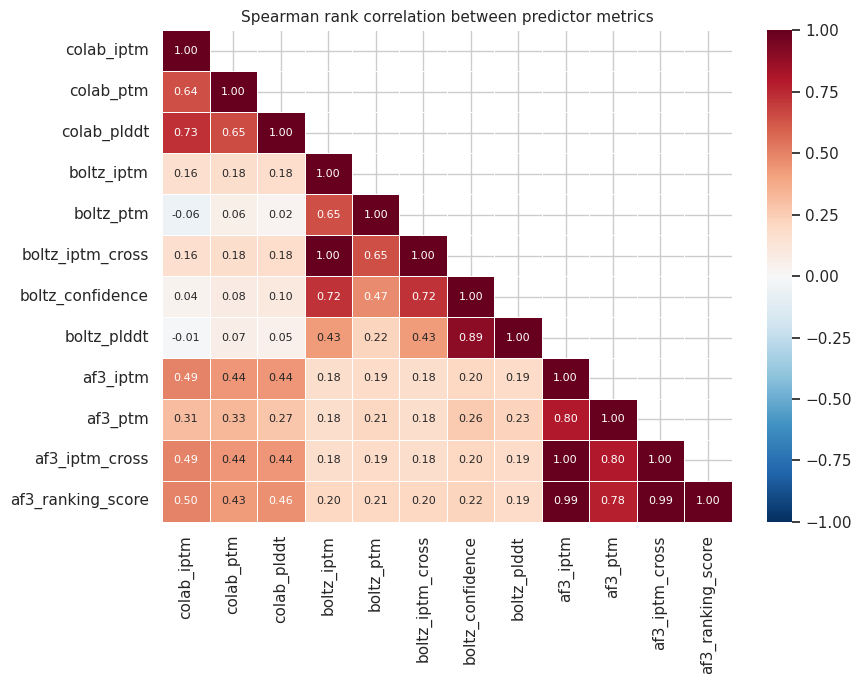

In [11]:
corr_cols = [c for c in [
    'colab_iptm', 'colab_ptm', 'colab_plddt',
    'boltz_iptm', 'boltz_ptm', 'boltz_iptm_cross', 'boltz_confidence', 'boltz_plddt',
    'af3_iptm', 'af3_ptm', 'af3_iptm_cross', 'af3_ranking_score',
] if c in df.columns]

corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Spearman rank correlation between predictor metrics', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# Mean iptm per protocol
df.groupby('protocol')[['colab_iptm', 'af3_iptm_cross']].mean()

,colab_iptm,af3_iptm_cross
protocol,,
gen_colabonly,0.441,0.620
gen_energy_A,0.481,0.750
gen_energy_B,0.354,0.640
gen_energy_C,0.474,0.727
opt_anneal_energy_A,0.222,0.685
opt_anneal_energy_B,0.229,0.708
opt_anneal_energy_C,0.263,0.650
opt_anneal_noenergy,0.366,0.643
opt_hard_energy_A,0.125,0.660


## 9. Rank correlation across predictors

In [13]:
key_metrics = {c: c for c in ['af3_iptm_cross', 'colab_iptm','boltz_iptm_cross' ] if c in df.columns}

df_rank = df[['seq', 'protocol'] + list(key_metrics)].copy()
for col in key_metrics:
    df_rank = df_rank.dropna(subset=list(key_metrics))
    df_rank[f'rank_{col}'] = df_rank[col].rank(ascending=False).astype(int)

rank_cols = [f'rank_{c}' for c in key_metrics]
print('Rank comparison (1 = best):')
display_df = df_rank[['seq', 'protocol'] + list(key_metrics) + rank_cols]
display_df = display_df.sort_values(rank_cols[0] if rank_cols else 'seq')
display_df

Rank comparison (1 = best):


,seq,protocol,af3_iptm_cross,colab_iptm,boltz_iptm_cross,rank_af3_iptm_cross,rank_colab_iptm,rank_boltz_iptm_cross
3,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,0.907,3,4,31
6,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,0.936,3,4,19
12,SHGYVYDALWNMEVL,opt_anneal_energy_C,0.820,0.495,0.947,3,6,13
23,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,0.907,3,2,31
26,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,0.936,3,2,19
36,EHMPRYWQFCRAWFL,opt_anneal_noenergy,0.810,0.739,0.766,6,1,40
43,CVCNVYWHFSRKGLL,opt_hard_energy_C,0.770,0.145,0.932,7,30,21
29,CVCNVYWHFSRKGLL,opt_anneal_energy_B,0.770,0.144,0.893,7,31,35
30,YVCNVFLHFARKETL,opt_anneal_energy_C,0.760,0.150,0.947,9,29,13
13,YVCNVFLHFARKETL,opt_anneal_energy_C,0.760,0.150,0.957,9,28,5


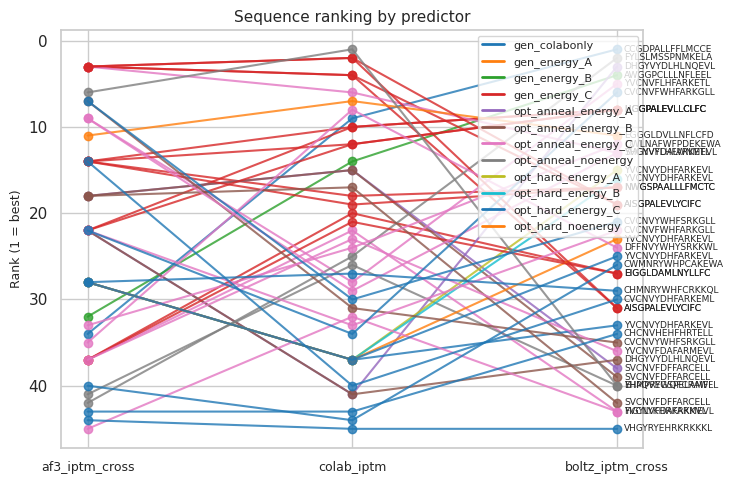

In [14]:
# Bump chart: rank per sequence for each predictor
if len(key_metrics) >= 2:
    fig, ax = plt.subplots(figsize=(max(7, len(key_metrics) * 2.5), 5))
    predictor_labels = list(key_metrics)
    x_pos = range(len(predictor_labels))

    for _, row in df_rank.iterrows():
        ranks = [row[f'rank_{c}'] for c in key_metrics]
        color = palette.get(row['protocol'], 'grey')
        ax.plot(x_pos, ranks, marker='o', color=color, alpha=0.8, lw=1.5)
        ax.annotate(row['seq'], (len(predictor_labels) - 1, ranks[-1]),
                    fontsize=6.5, va='center', xytext=(5, 0), textcoords='offset points')

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(predictor_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel('Rank (1 = best)', fontsize=9)
    ax.set_title('Sequence ranking by predictor', fontsize=11)
    handles = [plt.Line2D([0], [0], color=c, lw=2, label=p) for p, c in palette.items()]
    ax.legend(handles=handles, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()